### Visualization Hands'On

#### This file contains:

I did data visualization and data analysis tasks on cars dataset. This file contains various plots/graphs like:
- scatter plot
- bar plot
- heatmap (for correlation)
- pie chart
- violin plot
- categorical plots (bar, violin, swarm, boxen, strip) etc.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("dsenv/cars.csv", skipinitialspace = True)
df

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
0,14.0,8,350.0,165,4209.0,12,1972,US.
1,31.9,4,89.0,71,1925.0,14,1980,Europe.
2,17.0,8,302.0,140,3449.0,11,1971,US.
3,15.0,8,400.0,150,3761.0,10,1971,US.
4,30.5,4,98.0,63,2051.0,17,1978,US.
...,...,...,...,...,...,...,...,...
256,17.0,8,305.0,130,3840.0,15,1980,US.
257,36.1,4,91.0,60,1800.0,16,1979,Japan.
258,22.0,6,232.0,112,2835.0,15,1983,US.
259,18.0,6,232.0,100,3288.0,16,1972,US.


In [4]:
# Top Rows
df.head()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
0,14.0,8,350.0,165,4209.0,12,1972,US.
1,31.9,4,89.0,71,1925.0,14,1980,Europe.
2,17.0,8,302.0,140,3449.0,11,1971,US.
3,15.0,8,400.0,150,3761.0,10,1971,US.
4,30.5,4,98.0,63,2051.0,17,1978,US.


In [5]:
# Bottom rows
df.tail()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
256,17.0,8,305.0,130,3840.0,15,1980,US.
257,36.1,4,91.0,60,1800.0,16,1979,Japan.
258,22.0,6,232.0,112,2835.0,15,1983,US.
259,18.0,6,232.0,100,3288.0,16,1972,US.
260,22.0,6,250.0,105,3353.0,15,1977,US.


In [6]:
# check datatypes of each column
df.dtypes

mpg            float64
cylinders        int64
cubicinches    float64
hp               int64
weightlbs      float64
time-to-60       int64
year             int64
brand           object
dtype: object

In [7]:
# Null Check
df.isnull().sum()

mpg            0
cylinders      0
cubicinches    2
hp             0
weightlbs      3
time-to-60     0
year           0
brand          0
dtype: int64

In [8]:
# Shape of the dataset
df.shape

(261, 8)

In [9]:
# Duplicates Check
print(df.duplicated().sum())

# Another method to check duplicate values
print(df.duplicated().any())

0
False


In [10]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mpg          261 non-null    float64
 1   cylinders    261 non-null    int64  
 2   cubicinches  259 non-null    float64
 3   hp           261 non-null    int64  
 4   weightlbs    258 non-null    float64
 5   time-to-60   261 non-null    int64  
 6   year         261 non-null    int64  
 7   brand        261 non-null    object 
dtypes: float64(3), int64(4), object(1)
memory usage: 16.4+ KB


In [11]:
# Statistical Information about the dataset
df.describe()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year
count,261.000000,261.000000,259.000000,261.000000,258.000000,261.000000,261.000000
mean,23.144828,5.590038,200.918919,106.360153,3009.833333,15.547893,1976.819923
std,7.823570,1.733310,109.258305,40.499959,854.039019,2.910625,3.637696
min,10.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,1971.000000
25%,16.900000,4.000000,99.500000,75.000000,2248.000000,14.000000,1974.000000
50%,22.000000,6.000000,156.000000,95.000000,2867.500000,16.000000,1977.000000
75%,28.800000,8.000000,303.000000,138.000000,3670.000000,17.000000,1980.000000
max,46.600000,8.000000,455.000000,230.000000,4997.000000,25.000000,1983.000000


In [12]:
# How many unique brands are present in the dataset.
df['brand'].unique()

array(['US.', 'Europe.', 'Japan.'], dtype=object)

In [13]:
# Value counts of each brand
df['brand'].value_counts()

brand
US.        162
Japan.      51
Europe.     48
Name: count, dtype: int64

In [14]:
df[df['brand']=='Japan.']

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
9,37.7,4,89.0,62,2050.0,17,1982,Japan.
10,34.0,4,108.0,70,2245.0,17,1983,Japan.
16,31.8,4,85.0,65,2020.0,19,1980,Japan.
18,24.0,4,113.0,95,2278.0,16,1973,Japan.
20,37.2,4,86.0,65,2019.0,16,1981,Japan.
24,38.1,4,89.0,60,1968.0,19,1981,Japan.
25,33.0,4,91.0,53,1795.0,17,1977,Japan.
26,31.0,4,71.0,65,1773.0,19,1972,Japan.
30,27.0,4,97.0,88,2130.0,15,1971,Japan.
32,23.0,4,120.0,97,2506.0,15,1973,Japan.


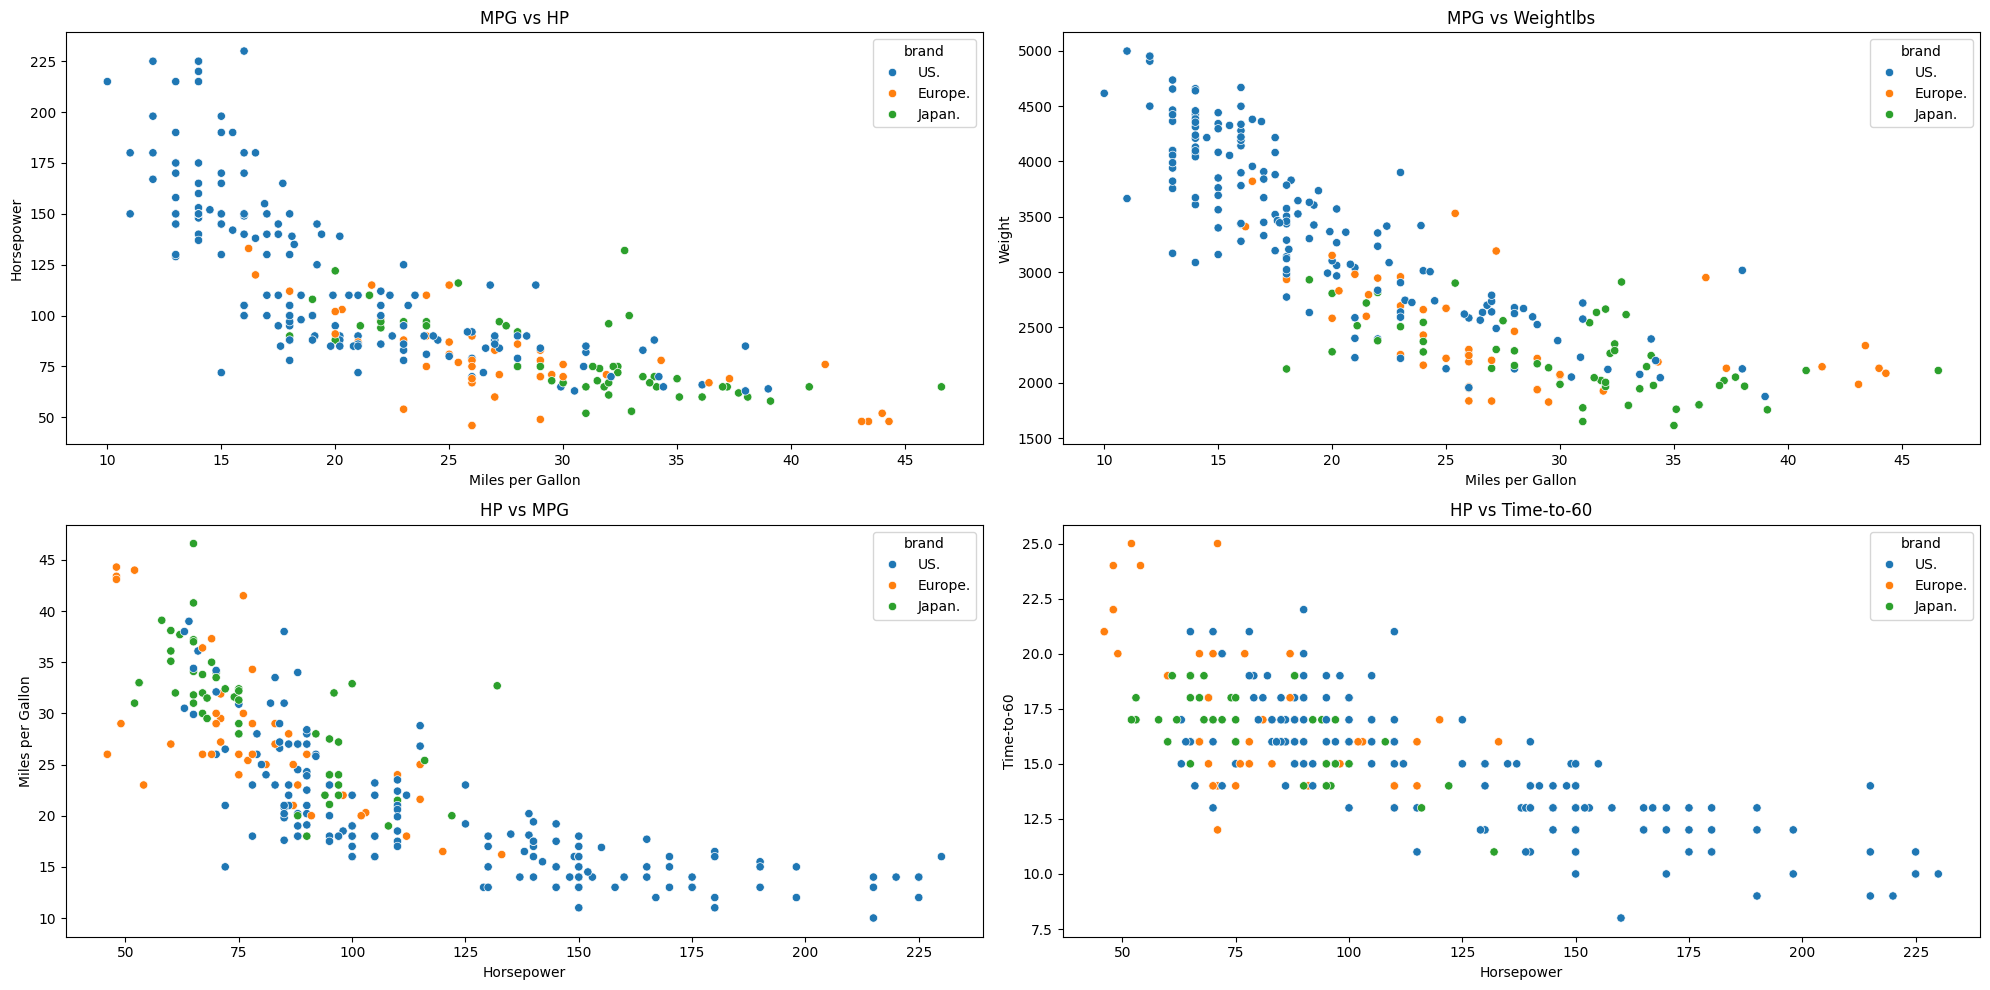

In [15]:
# Create a Scatter plot for the following data, make sure all the plots appear in the same place with x-labels and y-labels evenly spaced.

# A. Create a Scatter plot with between (mpg-hp, mpg-weight), and (hp-mpg, hp-time-to-60) with respect to each brand

fig = plt.subplots(2, 2, figsize = (20, 10))

plt.subplot(2,2,1)
sns.scatterplot(x = "mpg", y = "hp", hue = "brand", data = df)
plt.xlabel("Miles per Gallon")
plt.ylabel("Horsepower")
plt.title("MPG vs HP")


plt.subplot(2,2,2)
sns.scatterplot(x = "mpg", y = "weightlbs", hue = 'brand', data = df)
plt.xlabel("Miles per Gallon")
plt.ylabel("Weight")
plt.title("MPG vs Weightlbs")

plt.subplot(2,2,3)
sns.scatterplot(x = 'hp', y = 'mpg', hue = 'brand', data = df)
plt.xlabel('Horsepower')
plt.ylabel('Miles per Gallon')
plt.title("HP vs MPG")

plt.subplot(2,2,4)
sns.scatterplot(x = 'hp', y = 'time-to-60', hue = 'brand', data = df)
plt.xlabel("Horsepower")
plt.ylabel("Time-to-60")
plt.title('HP vs Time-to-60')

plt.tight_layout()
plt.show()

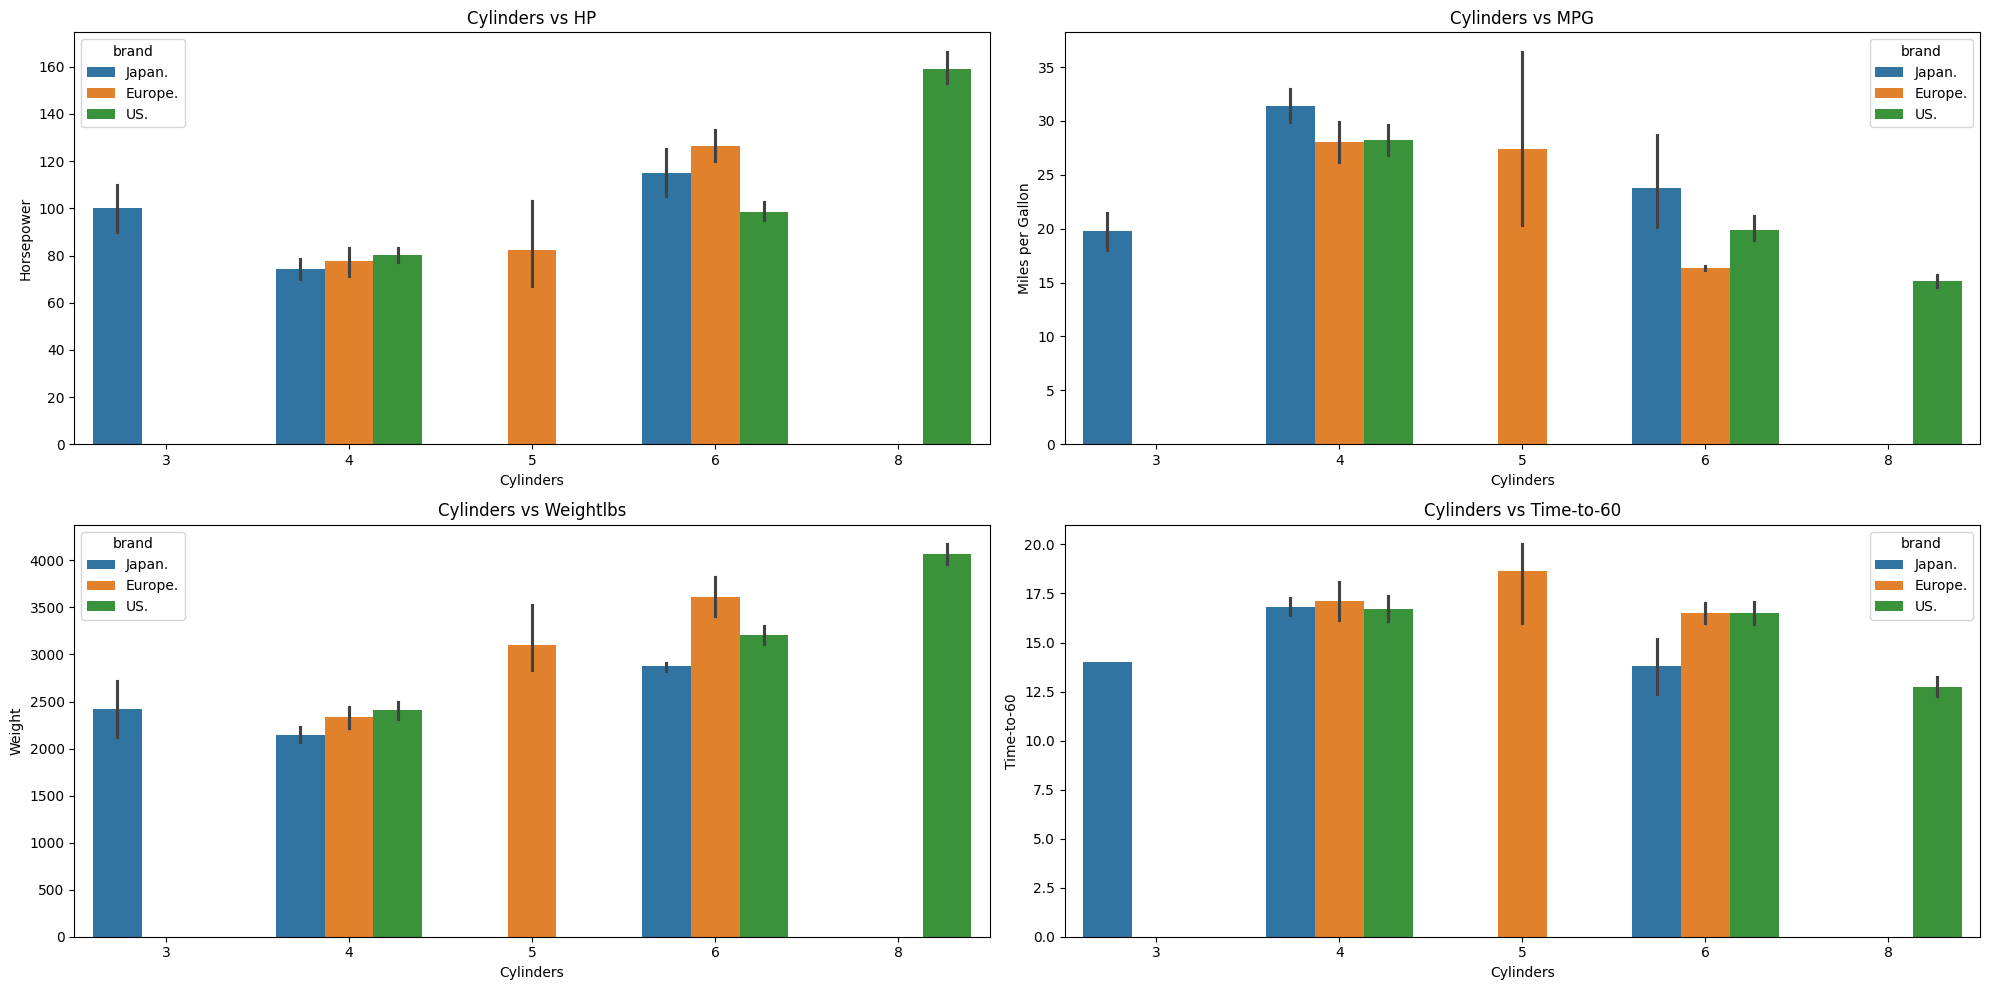

In [16]:
# Create a bar plot for th following, make sure all the plots appear in the same place with x-labels and y-labels evenly spaced.

fig = plt.subplots(2, 2, figsize = (20,10))

plt.subplot(2,2,1)
sns.barplot(x='cylinders', y='hp', hue='brand', data = df)
plt.xlabel('Cylinders')
plt.ylabel('Horsepower')
plt.title('Cylinders vs HP')

plt.subplot(2,2,2)
sns.barplot(x='cylinders', y='mpg', hue='brand', data = df)
plt.xlabel('Cylinders')
plt.ylabel('Miles per Gallon')
plt.title('Cylinders vs MPG')

plt.subplot(2,2,3)
sns.barplot(x='cylinders', y='weightlbs', hue='brand', data = df)
plt.xlabel('Cylinders')
plt.ylabel('Weight')
plt.title('Cylinders vs Weightlbs')

plt.subplot(2,2,4)
sns.barplot(x='cylinders', y='time-to-60', hue='brand', data = df)
plt.xlabel('Cylinders')
plt.ylabel('Time-to-60')
plt.title('Cylinders vs Time-to-60')

plt.tight_layout()
plt.show()

In [17]:
# Create a heatmap for the entire data to study correlation between each of the columns.
df.corr(numeric_only=True)

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year
mpg,1.000000,-0.776710,-0.803964,-0.774905,-0.825234,0.509070,0.550441
cylinders,-0.776710,1.000000,0.951452,0.845155,0.896093,-0.578161,-0.322239
cubicinches,-0.803964,0.951452,1.000000,0.906902,0.930027,-0.613199,-0.350293
hp,-0.774905,0.845155,0.906902,1.000000,0.861028,-0.744873,-0.383869
weightlbs,-0.825234,0.896093,0.930027,0.861028,1.000000,-0.480772,-0.281119
time-to-60,0.509070,-0.578161,-0.613199,-0.744873,-0.480772,1.000000,0.312311
year,0.550441,-0.322239,-0.350293,-0.383869,-0.281119,0.312311,1.000000


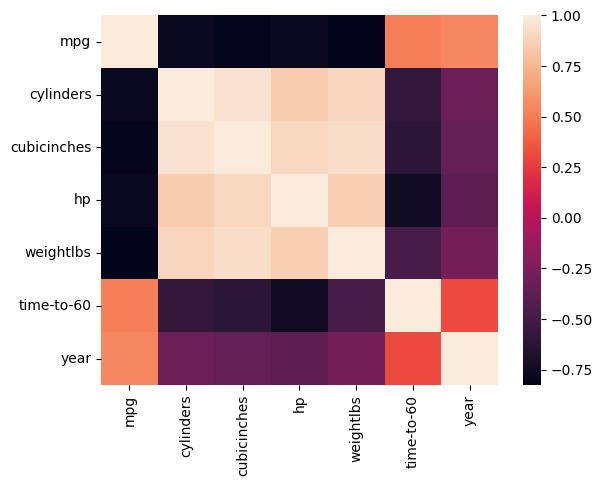

In [20]:
sns.heatmap(df.corr(numeric_only= True))
plt.show()

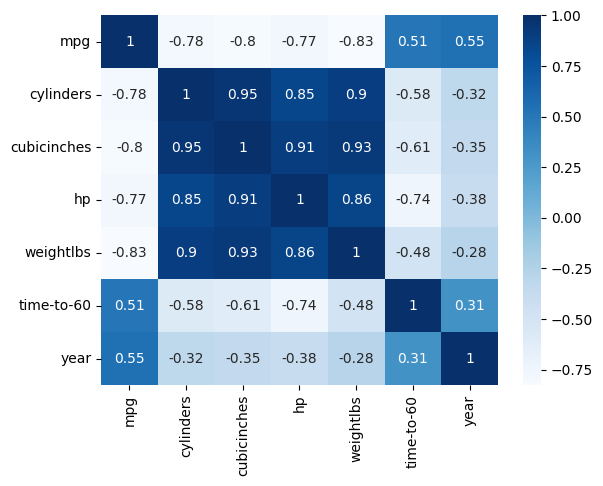

In [21]:
# Another way of showing correlation between variables.
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap='Blues')
plt.show()

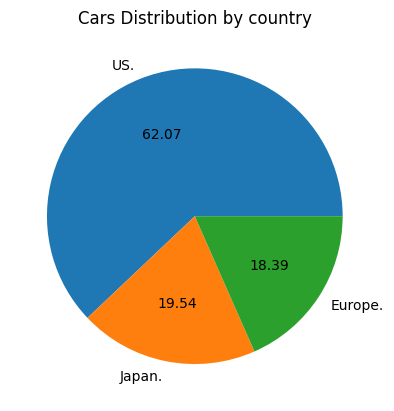

In [28]:
# Create a pie chart for the 'Brand' column and their distribution in the data.
x = df['brand'].value_counts()

plt.pie(x, labels=x.index, autopct='%.2f')
plt.title('Cars Distribution by country')
plt.show()

In [24]:
print("Total no. of rows:", 162+51+48)

Total no. of rows: 261


In [25]:
print("Total no. of US Brands:", (162/261)*100)

Total no. of US Brands: 62.06896551724138


In [26]:
print("Total no. of Japan Brands:", (51/261)*100)

Total no. of Japan Brands: 19.54022988505747


In [27]:
print("Total no. of Europe Brands:", (48/261)*100)

Total no. of Europe Brands: 18.39080459770115


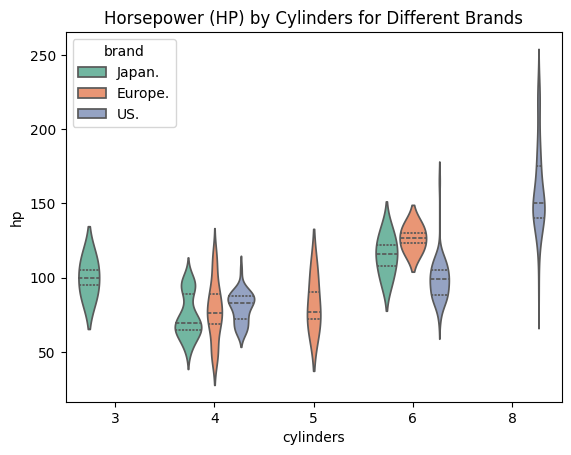

In [52]:
# Create a Violin plots for the following

# a. hp, mpg, time-to-60 with respect to the number of cylinders for each brand.
sns.violinplot(x='cylinders', y='hp', hue = 'brand', palette = 'Set2', inner='quartile', data = df)
plt.title("Horsepower (HP) by Cylinders for Different Brands")
plt.show()

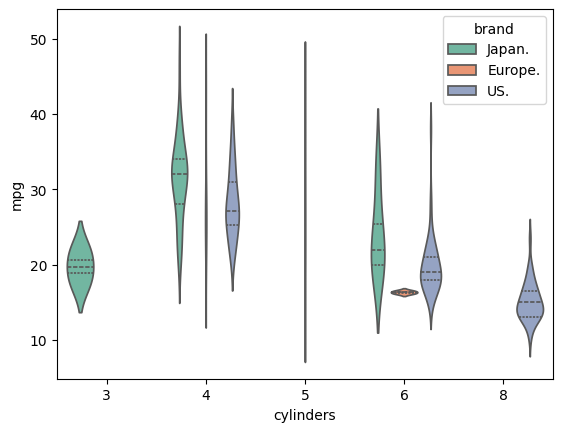

In [39]:
sns.violinplot(x='cylinders', y='mpg', hue = 'brand', palette = 'Set2', inner='quartile', data = df)
plt.show()

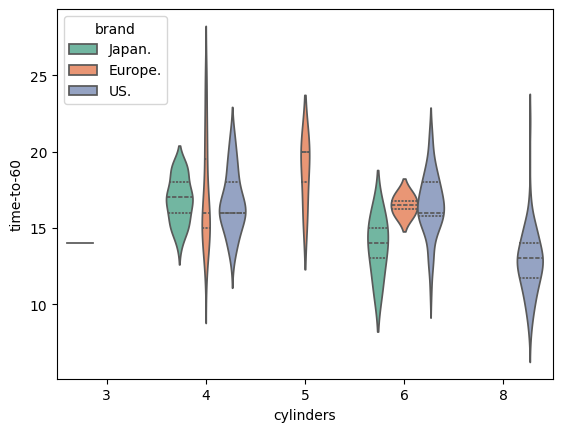

In [40]:
sns.violinplot(x='cylinders', y='time-to-60', hue = 'brand', palette = 'Set2', inner='quartile', data = df)
plt.show()

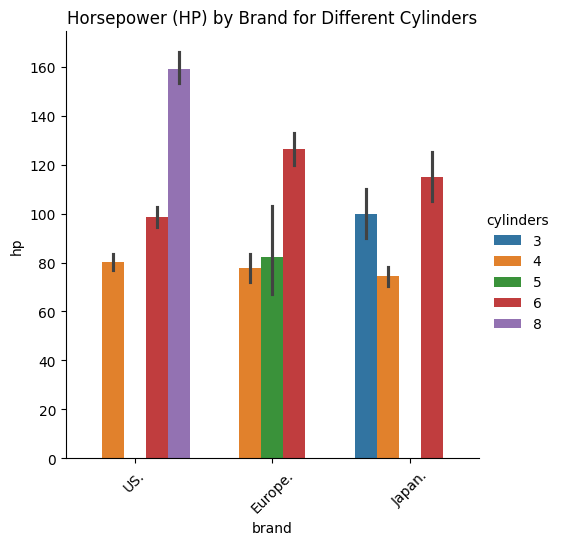

In [55]:
# Create a cateo=gorical plots for the following:
# HP, mpg, time-to-60, weight, cubic inches with respect to each brand for various cylinders.

# Convert cylinders to categorical (important for category plots)
df["cylinders"] = df["cylinders"].astype("category")

sns.catplot(x="brand", y="hp",hue = 'cylinders', data=df, kind="bar")
plt.title("Horsepower (HP) by Brand for Different Cylinders")
plt.xticks(rotation=45)
plt.show()


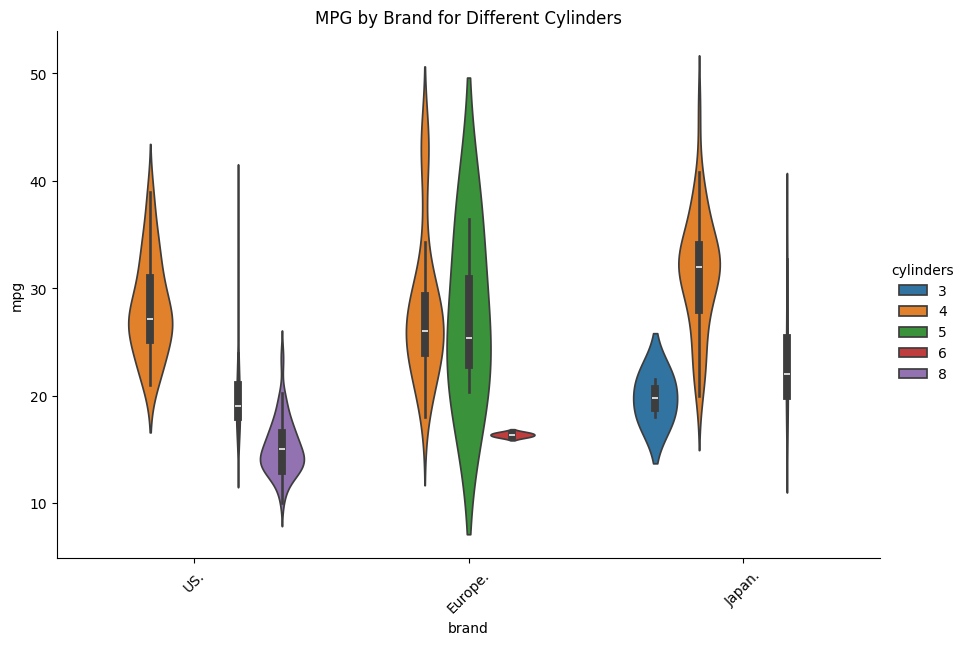

In [57]:
sns.catplot(x="brand",y="mpg",hue="cylinders",kind="violin",height=6,aspect=1.5,split=False, data = df)
plt.title("MPG by Brand for Different Cylinders")
plt.xticks(rotation=45)
plt.show()

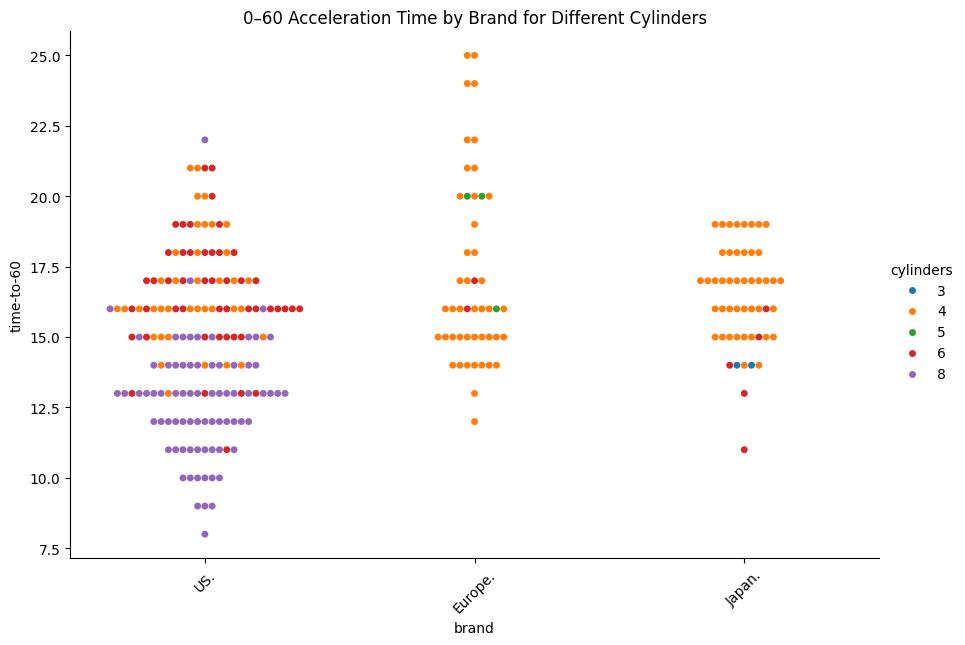

In [58]:
sns.catplot(x="brand", y="time-to-60",hue = 'cylinders', data=df, kind="swarm",
    height=6,
    aspect=1.5)
plt.title("0–60 Acceleration Time by Brand for Different Cylinders")
plt.xticks(rotation=45)
plt.show()

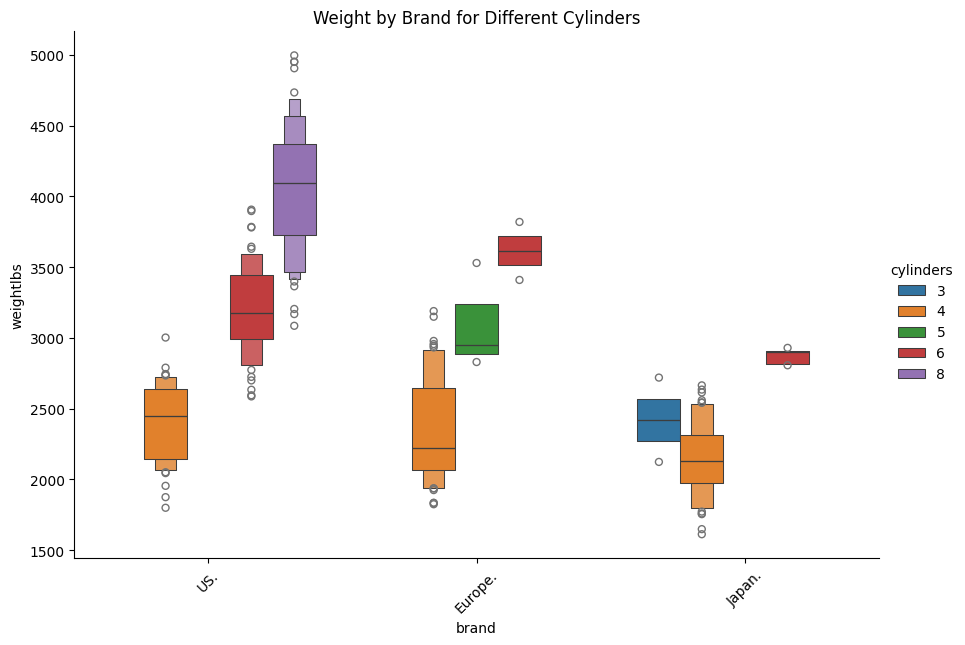

In [60]:
sns.catplot(
    x="brand",
    y="weightlbs",
    hue="cylinders",
    kind="boxen",
    height=6,
    aspect=1.5,
    data = df
)
plt.title("Weight by Brand for Different Cylinders")
plt.xticks(rotation=45)
plt.show()

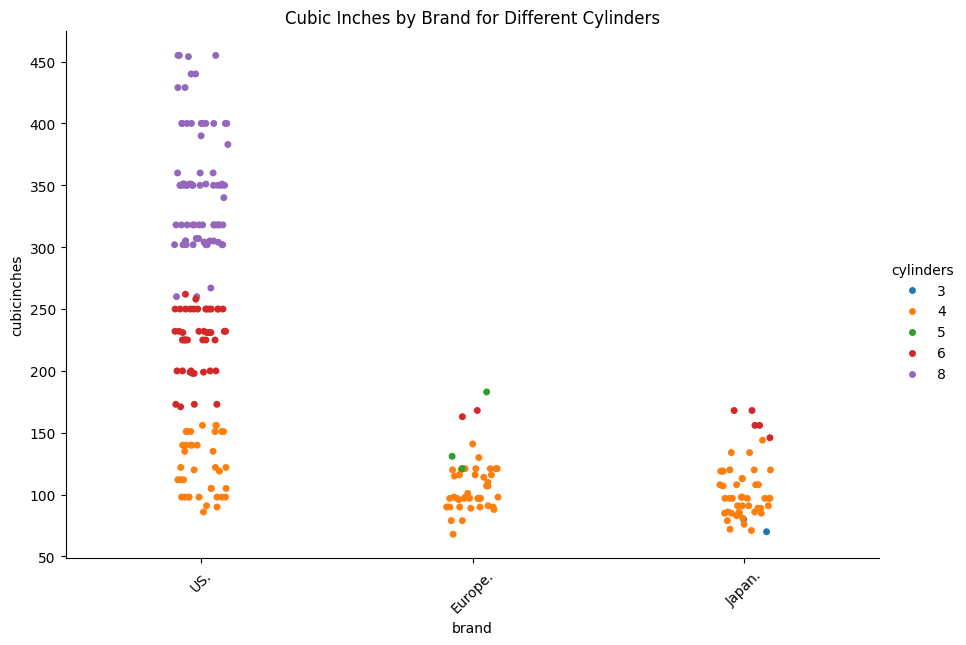

In [62]:
sns.catplot(
    x="brand",
    y="cubicinches",
    hue="cylinders",
    kind="strip",
    height=6,
    aspect=1.5, 
    data = df
)
plt.title("Cubic Inches by Brand for Different Cylinders")
plt.xticks(rotation=45)
plt.show()